<a href="https://colab.research.google.com/github/sissi820li/APS360/blob/main/MisinformationDetectionProject/MisinformationDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Changes made to final MisinfoLSTM architecture that is different from the prototype:

1. Learning rate: Change from 0.01 to 0.001. The Adam optimizer usually performs better with a lower rate, usually around 0.001 or 0.005. A high learning rate caused the prototype model to overshoot optimal weights so for the final model, the learning rate is lowered.

2. Add a 0.2 dropout & dropout layer: This will prevent the neural network to focus on a specific word or phrase that appears frequently in the "fake" category when training. The model will be forced to drop 20% of neurons during each forward pass, preventing it from focusing on one "trigger" neuron. This will force it to look at broader sentence context, distribute its learning, and only learn the most meaningful patterns.

3. Add Weight Decay or L2 Regularization: Prevent the model from becoming too "confident" and connecting larger weights to certian vocab words as it trains. This will keep this weights small and ensure the model does not create rigid rules that will fail on new data. 

In [1]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader, TensorDataset
import re
from nltk.corpus import stopwords
import json

In [39]:
class MisinfoLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim=1, n_layers=1, bidirectional=True):
        super().__init__()
        self.name = "MisinfoLSTM"
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # Set dropout=0 if n_layers=1, as it has no effect otherwise
        self.lstm = nn.LSTM(embedding_dim, 
                            hidden_dim, 
                            num_layers=n_layers, 
                            bidirectional=bidirectional, 
                            batch_first=True,
                            dropout=0.0) 
        
        linear_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.dropout = nn.Dropout(0.2) 
        self.fc = nn.Linear(linear_input_dim, output_dim)
        #self.sigmoid = nn.Sigmoid()

    def forward(self, text):
        embedded = self.embedding(text)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        if self.lstm.bidirectional:
            hidden_final = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden_final = hidden[-1,:,:]

        dropped_out = self.dropout(hidden_final)
        dense_outputs = self.fc(dropped_out)
        
        return (dense_outputs).squeeze()
def get_model_name(name, batch_size, learning_rate, epoch):
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
                                                   batch_size,
                                                   learning_rate,
                                                   epoch)
    return path

Helper Functions and Training

In [44]:
def evaluate(net, loader, criterion):
    total_loss = 0.0
    total_err = 0.0
    total_epoch = 0
    
    with torch.no_grad():
        for i, data in enumerate(loader, 0):
            inputs, labels = data
            
            labels = labels.float() 
            
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            probs = torch.sigmoid(outputs) # Turn logits into probabilities (0 to 1)
            predicted = (probs > 0.5).float() # Threshold the probabilities at 0.5
            
            corr = predicted != labels
            total_err += int(corr.sum())
            total_loss += loss.item()
            total_epoch += len(labels)
            
    err = float(total_err) / total_epoch
    loss = float(total_loss) / (i + 1)
    return err, loss

def train_net(net, train_loader, val_loader, batch_size=32, learning_rate=0.001, num_epochs=10):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(net.parameters(), lr=learning_rate, weight_decay=1e-4) # Add weight decay to Adam Optimizer

    train_err = np.zeros(num_epochs)
    train_loss = np.zeros(num_epochs)
    val_err = np.zeros(num_epochs)
    val_loss = np.zeros(num_epochs)

    start_time = time.time()
    for epoch in range(num_epochs): 
        total_train_loss = 0.0
        total_train_err = 0.0
        total_epoch = 0
        
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data
            
            # Convert labels to float
            labels = labels.float()
            
            optimizer.zero_grad()
            
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            # Calculate the statistics using rounding for binary outputs
            predicted = torch.round(outputs)
            corr = predicted != labels
            total_train_err += int(corr.sum())
            total_train_loss += loss.item()
            total_epoch += len(labels)
            
        train_err[epoch] = float(total_train_err) / total_epoch
        train_loss[epoch] = float(total_train_loss) / (i+1)
        
        # Evaluate on the validation set
        val_err[epoch], val_loss[epoch] = evaluate(net, val_loader, criterion)
        
        print(("Epoch {}: Train err: {:.4f}, Train loss: {:.4f} | "+
               "Validation err: {:.4f}, Validation loss: {:.4f}").format(
                   epoch + 1,
                   train_err[epoch],
                   train_loss[epoch],
                   val_err[epoch],
                   val_loss[epoch]))
        
        # Save current model to a file
        model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
        torch.save(net.state_dict(), model_path)
        
    print('Finished Training')
    end_time = time.time()
    elapsed_time = end_time - start_time
    print("Total time elapsed: {:.2f} seconds".format(elapsed_time))
    
    np.savetxt("{}_train_err.csv".format(model_path), train_err)
    np.savetxt("{}_train_loss.csv".format(model_path), train_loss)
    np.savetxt("{}_val_err.csv".format(model_path), val_err)
    np.savetxt("{}_val_loss.csv".format(model_path), val_loss)
    
    return model_path

In [41]:
def plot_training_curve(path):
    """ Plots the training curve for a model run, given the csv files
    containing the train/validation error/loss.

    Args:
        path: The base path of the csv files produced during training
    """
    import matplotlib.pyplot as plt
    train_err = np.loadtxt("{}_train_err.csv".format(path))
    val_err = np.loadtxt("{}_val_err.csv".format(path))
    train_loss = np.loadtxt("{}_train_loss.csv".format(path))
    val_loss = np.loadtxt("{}_val_loss.csv".format(path))
    plt.title("Train vs Validation Error")
    n = len(train_err) # number of epochs
    plt.plot(range(1,n+1), train_err, label="Train")
    plt.plot(range(1,n+1), val_err, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend(loc='best')
    plt.show()
    plt.title("Train vs Validation Loss")
    plt.plot(range(1,n+1), train_loss, label="Train")
    plt.plot(range(1,n+1), val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    plt.show()

Train and Evaluate the model

In [45]:
# Load the data
loaded_train = torch.load('dataset/dataset_tensors_split/train_tensors.pt')
train_dataset = TensorDataset(loaded_train['features'], loaded_train['labels'])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

loaded_val = torch.load('dataset/dataset_tensors_split/val_tensors.pt')
val_dataset = TensorDataset(loaded_val['features'], loaded_val['labels'])
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

loaded_test = torch.load('dataset/dataset_tensors_split/test_tensors.pt')
test_dataset = TensorDataset(loaded_test['features'], loaded_test['labels'])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Find highest token ID in training and validation tensors
max_train_id = loaded_train['features'].max().item()
max_val_id = loaded_val['features'].max().item()

# The vocab size must be greater than highest token ID
VOCAB_SIZE = max(max_train_id, max_val_id) + 1 
EMBEDDING_DIM = 100
HIDDEN_DIM = 64

High training error is caused by the 0.2 dropout, which handicaps the model by disabling 20% of neurons during training. During testing and validation, dropout = 0 so model can then use it's full power to evaluate. 

Epoch 1: Train err: 0.4287, Train loss: 0.6100 | Validation err: 0.0741, Validation loss: 0.3762
Epoch 2: Train err: 0.9181, Train loss: 0.2209 | Validation err: 0.0453, Validation loss: 0.1374
Epoch 3: Train err: 0.9877, Train loss: 0.0823 | Validation err: 0.0247, Validation loss: 0.0815
Epoch 4: Train err: 0.9938, Train loss: 0.0509 | Validation err: 0.0206, Validation loss: 0.0785
Epoch 5: Train err: 0.9947, Train loss: 0.0367 | Validation err: 0.0247, Validation loss: 0.0696
Epoch 6: Train err: 0.9947, Train loss: 0.0201 | Validation err: 0.0247, Validation loss: 0.0818
Epoch 7: Train err: 1.0000, Train loss: 0.0139 | Validation err: 0.0329, Validation loss: 0.1404
Epoch 8: Train err: 0.9956, Train loss: 0.0390 | Validation err: 0.0370, Validation loss: 0.0978
Epoch 9: Train err: 0.9974, Train loss: 0.0187 | Validation err: 0.0165, Validation loss: 0.0707
Epoch 10: Train err: 0.9991, Train loss: 0.0104 | Validation err: 0.0165, Validation loss: 0.0664
Epoch 11: Train err: 1.0000, 

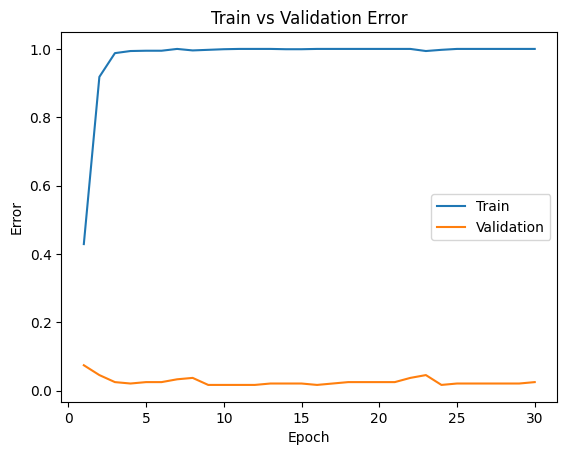

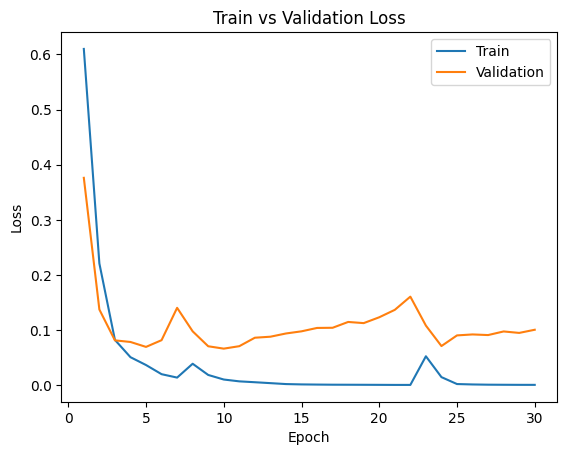

In [ ]:
misinfo = MisinfoLSTM(vocab_size=VOCAB_SIZE, embedding_dim=EMBEDDING_DIM, hidden_dim=HIDDEN_DIM, n_layers=2, bidirectional=True)

# Train and plot
model_path = train_net(misinfo, train_loader=train_loader, val_loader=val_loader, batch_size=32, learning_rate=0.001, num_epochs=30)
plot_training_curve(model_path)

Test the model

In [48]:
criterion = nn.BCEWithLogitsLoss()
test_err, test_loss = evaluate(misinfo, test_loader, criterion)
test_accuracy = 1.0 - test_err

print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

Final Test Accuracy: 97.95%
Final Test Loss: 0.1291


Test the model on newly collected data from recent tweets

In [49]:
loaded_test_final = torch.load('dataset/dataset_tensors_split/test_final_tensors.pt')
test_final_dataset = TensorDataset(loaded_test_final['features'], loaded_test_final['labels'])
test_final_loader = DataLoader(test_final_dataset, batch_size=32, shuffle=False)

test_err, test_loss = evaluate(misinfo, test_final_loader, criterion)
test_accuracy = 1.0 - test_err

print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

Final Test Accuracy: 96.30%
Final Test Loss: 0.2351


Sample of input and output for the final model

In [63]:
stop_words = set(stopwords.words('english'))

# Import vocab dictionary that was created when processing/cleaning datasets
vocab_file = 'dataset/dataset_tensors_split/vocab_to_int.json'
with open(vocab_file, 'r') as f:
    vocab_to_int = json.load(f)

def predict_single_claim(model, claim_text, vocab_to_int, seq_length=50):
    # Clean claim
    text = str(claim_text).lower()
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    tokens = [word for word in words if word not in stop_words]
    tokens = tokens[:seq_length]
    
    indices = [vocab_to_int.get(word, 1) for word in tokens] # Convert to integers using vocab dictionary
    
    # Pad features
    features = torch.zeros(seq_length, dtype=torch.int64)
    if len(indices) > 0:
        features[:len(indices)] = torch.tensor(indices)
    
    input_tensor = features.unsqueeze(0) 
    
    with torch.no_grad():
        output = model(input_tensor) # Raw logit
        # Apply sigmoid manually for inference
        prob = torch.sigmoid(output).item() 
            
    label = "Fake" if prob > 0.5 else "True"
    return label, prob

easy_fake = 'Drinking water cures COVID'
label, confidence = predict_single_claim(misinfo, easy_fake, vocab_to_int)
print(f"The claim the model is asked to analyze: {easy_fake}")
print(f"Model confidence: {confidence}")
print(f"The model's prediction is: {label}")
print(f"The real label for this claim is: Fake")

hard_fake = 'Emerging observational data suggests that certain dietary supplements may provide better long-term protection than standard prophylactic interventions for some individuals.'
label2, confidence = predict_single_claim(misinfo, hard_fake, vocab_to_int)
print(f"\nThe claim the model is asked to analyze: {hard_fake}")
print(f"Model confidence: {confidence}")
print(f"The model's prediction is: {label2}")
print(f"The real label for this claim is: Fake")

hard_fake2 = 'Research indicates that asymptomatic individuals may not contribute significantly to viral transmission, suggesting that social distancing protocols may be less impactful than previously modeled.'
label3, confidence = predict_single_claim(misinfo, hard_fake2, vocab_to_int)
print(f"\nThe claim the model is asked to analyze: {hard_fake2}")
print(f"Model confidence: {confidence}")
print(f"The model's prediction is: {label3}")
print(f"The real label for this claim is: Fake")

The claim the model is asked to analyze: Drinking water cures COVID
Model confidence: 0.99977046251297
The model's prediction is: Fake
The real label for this claim is: Fake

The claim the model is asked to analyze: Emerging observational data suggests that certain dietary supplements may provide better long-term protection than standard prophylactic interventions for some individuals.
Model confidence: 0.9692357182502747
The model's prediction is: Fake
The real label for this claim is: Fake

The claim the model is asked to analyze: Research indicates that asymptomatic individuals may not contribute significantly to viral transmission, suggesting that social distancing protocols may be less impactful than previously modeled.
Model confidence: 0.004378861747682095
The model's prediction is: True
The real label for this claim is: Fake


Quantitative Results

In [ ]:
# False Positive and False Negative Rates
import torch

def get_fp_fn_rates(model, data_loader):
    fp = 0 # Predicted 1, Actual 0
    tn = 0 # Predicted 0, Actual 0
    fn = 0 # Predicted 0, Actual 1
    tp = 0 # Predicted 1, Actual 1

    model.eval()
    with torch.no_grad():
        # Grab one batch
        sequences, labels = next(iter(val_loader))
        outputs = model(sequences)
        probs = torch.sigmoid(outputs).squeeze()
        print("Probabilities the model is outputting:")
        print(probs)
        for sequences, labels in data_loader:
            outputs = model(sequences)
            probs = torch.sigmoid(outputs).squeeze() 
            preds = (probs > 0.5).int()
            labels = labels.int()

            fp += ((preds == 1) & (labels == 0)).sum().item()
            tn += ((preds == 0) & (labels == 0)).sum().item()
            fn += ((preds == 0) & (labels == 1)).sum().item()
            tp += ((preds == 1) & (labels == 1)).sum().item()
            
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    print(f"False Positive Rate: {fpr:.4f} ({fp} FPs out of {fp + tn} actual True claims)")
    print(f"False Negative Rate: {fnr:.4f} ({fn} FNs out of {fn + tp} actual Fake claims)")

get_fp_fn_rates(misinfo, val_loader)
#get_fp_fn_rates(misinfo, test_final_loader)

Probabilities the model is outputting:
tensor([4.3159e-04, 9.9933e-01, 3.2032e-04, 9.9939e-01, 1.1982e-03, 9.9975e-01,
        4.0006e-04, 1.0860e-03, 5.5866e-04, 2.4771e-04, 3.8033e-04, 5.3139e-04,
        9.9966e-01, 9.9972e-01, 9.9977e-01, 3.9314e-04, 3.5171e-04, 9.9941e-01,
        2.8702e-04, 9.9974e-01, 9.8303e-01, 9.9956e-01, 9.0818e-04, 4.9730e-04,
        9.9959e-01, 9.9942e-01, 3.3108e-04, 4.2593e-04, 9.9933e-01, 2.1613e-04,
        9.9945e-01, 9.9938e-01])
False Positive Rate: 0.0397 (5 FPs out of 126 actual True claims)
False Negative Rate: 0.0085 (1 FNs out of 117 actual Fake claims)


In [53]:
#Other Evaluation Metrics: Precision, Recall, F1 Score
from sklearn.metrics import classification_report, confusion_matrix

def get_detailed_metrics(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for sequences, labels in data_loader:
            outputs = model(sequences)
            probs = torch.sigmoid(outputs).squeeze()
            preds = (probs > 0.5).int()
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.int().cpu().numpy())

    # Generate report
    report = classification_report(all_labels, all_preds, target_names=["True", "Fake"])
    matrix = confusion_matrix(all_labels, all_preds)
    
    print("Classification Report:")
    print(report)
    print("\nConfusion Matrix:")
    print(matrix)

print("\n--- Test Set Metrics ---")
get_detailed_metrics(misinfo, test_loader)

print("\n--- Final Test Set Metrics ---")
get_detailed_metrics(misinfo, test_final_loader)


--- Test Set Metrics ---
Classification Report:
              precision    recall  f1-score   support

        True       0.98      0.99      0.98       135
        Fake       0.98      0.97      0.98       109

    accuracy                           0.98       244
   macro avg       0.98      0.98      0.98       244
weighted avg       0.98      0.98      0.98       244


Confusion Matrix:
[[133   2]
 [  3 106]]

--- Final Test Set Metrics ---
Classification Report:
              precision    recall  f1-score   support

        True       0.00      0.00      0.00         0
        Fake       1.00      0.96      0.98        27

    accuracy                           0.96        27
   macro avg       0.50      0.48      0.49        27
weighted avg       1.00      0.96      0.98        27


Confusion Matrix:
[[ 0  0]
 [ 1 26]]


c:\Users\sissi\OneDrive\Desktop\Code\APS360\APS360\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sissi\OneDrive\Desktop\Code\APS360\APS360\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sissi\OneDrive\Desktop\Code\APS360\APS360\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me